# Normalized Data EDA

This notebook is strictly for exploratory data analysis and data-quality checks on normalized Parquet files. It does not build features, targets, correlations, or IC tables.

In [1]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

if "notebooks" not in sys.path:
    sys.path.append("notebooks")

from advanced_features import discover_datasets

ROOT = Path(os.environ.get("MODL_WS_NORMALIZED_DIR", "/mnt/burner-archive/ws_normalized")).expanduser()
DATE = os.environ.get("MODL_VIEW_DATE", "2026-06-30")
DATE_TAG = datetime.strptime(DATE, "%Y-%m-%d").strftime("%y-%m-%d")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_colwidth", 180)
pl.Config.set_tbl_cols(240)
pl.Config.set_tbl_rows(24)

DATASETS = discover_datasets(ROOT, DATE_TAG)
if not DATASETS:
    raise FileNotFoundError(f"No normalized Parquet files found under {ROOT} for {DATE}")

ROOT, DATE, DATE_TAG, len(DATASETS)


(PosixPath('/mnt/burner-archive/ws_normalized'), '2026-06-30', '26-06-30', 14)

## File Inventory

In [2]:
file_rows = []
for key, path in sorted(DATASETS.items()):
    p = Path(path)
    exchange, symbol, dataset = key.split("/")
    file_rows.append({"exchange": exchange, "symbol": symbol, "dataset": dataset, "key": key, "size_mb": round(p.stat().st_size / 1_000_000, 3), "path": str(p)})
files = pd.DataFrame(file_rows)
files

,exchange,symbol,dataset,key,size_mb,path
0,bitfinex,tbtcusd,book_l25,bitfinex/tbtcusd/book_l25,1.543,/mnt/burner-archive/ws_normalized/bitfinex/tbtcusd/book_l25/tbtcusd_book_l25_26-06-30.parquet
1,bitfinex,tbtcusd,trades,bitfinex/tbtcusd/trades,0.075,/mnt/burner-archive/ws_normalized/bitfinex/tbtcusd/trades/tbtcusd_trades_26-06-30.parquet
2,deribit,btc,incremental_ticker,deribit/btc/incremental_ticker,27.255,/mnt/burner-archive/ws_normalized/deribit/btc/incremental_ticker/btc_incremental_ticker_26-06-30.parquet
3,deribit,btc,instrument_state,deribit/btc/instrument_state,0.063,/mnt/burner-archive/ws_normalized/deribit/btc/instrument_state/btc_instrument_state_26-06-30.parquet
4,deribit,btc,instruments,deribit/btc/instruments,0.015,/mnt/burner-archive/ws_normalized/deribit/btc/instruments/btc_instruments_26-06-30.parquet
5,deribit,btc,trades,deribit/btc/trades,0.141,/mnt/burner-archive/ws_normalized/deribit/btc/trades/btc_trades_26-06-30.parquet
6,hibachi,btc_usdt-p,funding,hibachi/btc_usdt-p/funding,0.162,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/funding/btc_usdt-p_funding_26-06-30.parquet
7,hibachi,btc_usdt-p,orderbook,hibachi/btc_usdt-p/orderbook,1.151,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/orderbook/btc_usdt-p_orderbook_26-06-30.parquet
8,hibachi,btc_usdt-p,prices,hibachi/btc_usdt-p/prices,0.377,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/prices/btc_usdt-p_prices_26-06-30.parquet
9,hibachi,btc_usdt-p,quotes,hibachi/btc_usdt-p/quotes,0.233,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/quotes/btc_usdt-p_quotes_26-06-30.parquet


## Row Counts And Time Coverage

In [3]:
def dataset_time_summary(key: str, path: str) -> dict:
    lf = pl.scan_parquet(path)
    schema = lf.collect_schema()
    exprs = [pl.len().alias("rows")]
    if "received_mts" in schema:
        exprs.extend([pl.col("received_mts").min().alias("min_received_mts"), pl.col("received_mts").max().alias("max_received_mts")])
    row = lf.select(exprs).collect().to_dicts()[0]
    row["key"] = key
    if row.get("min_received_mts") is not None:
        row["min_received_at"] = pd.to_datetime(row["min_received_mts"], unit="ms")
        row["max_received_at"] = pd.to_datetime(row["max_received_mts"], unit="ms")
        row["coverage_minutes"] = (row["max_received_mts"] - row["min_received_mts"]) / 60_000
    return row
coverage = pd.DataFrame([dataset_time_summary(key, path) for key, path in DATASETS.items()])
coverage = files.merge(coverage, on="key", how="left").sort_values(["exchange", "symbol", "dataset"])
coverage

,exchange,symbol,dataset,key,size_mb,path,rows,min_received_mts,max_received_mts,min_received_at,max_received_at,coverage_minutes
0,bitfinex,tbtcusd,book_l25,bitfinex/tbtcusd/book_l25,1.543,/mnt/burner-archive/ws_normalized/bitfinex/tbtcusd/book_l25/tbtcusd_book_l25_26-06-30.parquet,158343,1.782790e+12,1.782795e+12,2026-06-30 03:24:06.599,2026-06-30 04:53:15.765,89.152767
1,bitfinex,tbtcusd,trades,bitfinex/tbtcusd/trades,0.075,/mnt/burner-archive/ws_normalized/bitfinex/tbtcusd/trades/tbtcusd_trades_26-06-30.parquet,4458,1.782790e+12,1.782796e+12,2026-06-30 03:24:04.761,2026-06-30 05:01:18.708,97.232450
2,deribit,btc,incremental_ticker,deribit/btc/incremental_ticker,27.255,/mnt/burner-archive/ws_normalized/deribit/btc/incremental_ticker/btc_incremental_ticker_26-06-30.parquet,888043,1.782790e+12,1.782795e+12,2026-06-30 03:24:06.479,2026-06-30 04:53:00.985,88.908433
3,deribit,btc,instrument_state,deribit/btc/instrument_state,0.063,/mnt/burner-archive/ws_normalized/deribit/btc/instrument_state/btc_instrument_state_26-06-30.parquet,4504,1.782806e+12,1.782838e+12,2026-06-30 08:00:00.925,2026-06-30 16:51:00.533,530.993467
4,deribit,btc,instruments,deribit/btc/instruments,0.015,/mnt/burner-archive/ws_normalized/deribit/btc/instruments/btc_instruments_26-06-30.parquet,934,NaN,NaN,NaT,NaT,NaN
5,deribit,btc,trades,deribit/btc/trades,0.141,/mnt/burner-archive/ws_normalized/deribit/btc/trades/btc_trades_26-06-30.parquet,5252,1.782790e+12,1.782796e+12,2026-06-30 03:24:06.487,2026-06-30 05:01:50.351,97.731067
6,hibachi,btc_usdt-p,funding,hibachi/btc_usdt-p/funding,0.162,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/funding/btc_usdt-p_funding_26-06-30.parquet,17170,1.782790e+12,1.782795e+12,2026-06-30 03:24:05.138,2026-06-30 04:53:03.785,88.977450
7,hibachi,btc_usdt-p,orderbook,hibachi/btc_usdt-p/orderbook,1.151,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/orderbook/btc_usdt-p_orderbook_26-06-30.parquet,136117,1.782790e+12,1.782795e+12,2026-06-30 03:24:04.832,2026-06-30 04:53:03.170,88.972300
8,hibachi,btc_usdt-p,prices,hibachi/btc_usdt-p/prices,0.377,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/prices/btc_usdt-p_prices_26-06-30.parquet,34340,1.782790e+12,1.782795e+12,2026-06-30 03:24:05.138,2026-06-30 04:53:03.785,88.977450
9,hibachi,btc_usdt-p,quotes,hibachi/btc_usdt-p/quotes,0.233,/mnt/burner-archive/ws_normalized/hibachi/btc_usdt-p/quotes/btc_usdt-p_quotes_26-06-30.parquet,17170,1.782790e+12,1.782795e+12,2026-06-30 03:24:05.138,2026-06-30 04:53:03.785,88.977450


## Schema Overview

In [4]:
schema_rows = []
for key, path in DATASETS.items():
    schema = pl.scan_parquet(path).collect_schema()
    for column, dtype in schema.items():
        schema_rows.append({"key": key, "column": column, "dtype": str(dtype)})
schemas = pd.DataFrame(schema_rows)
schemas.head(120)

,key,column,dtype
0,bitfinex/tbtcusd/book_l25,exchange,String
1,bitfinex/tbtcusd/book_l25,symbol,String
2,bitfinex/tbtcusd/book_l25,received_at,String
3,bitfinex/tbtcusd/book_l25,received_mts,Int64
4,bitfinex/tbtcusd/book_l25,connection_id,String
...,...,...,...
115,deribit/btc/trades,strike,String
116,deribit/btc/trades,option_type,String
117,deribit/btc/trades,settlement_period,String
118,deribit/btc/trades,trade_timestamp,Int64


## Missingness

In [5]:
missing_rows = []
for key, path in DATASETS.items():
    lf = pl.scan_parquet(path)
    schema = lf.collect_schema()
    exprs = [pl.len().alias("rows")]
    exprs.extend([pl.col(column).null_count().alias(column) for column in schema])
    stats = lf.select(exprs).collect().to_dicts()[0]
    total = stats.pop("rows")
    for column, nulls in stats.items():
        missing_rows.append({"key": key, "column": column, "rows": total, "nulls": nulls, "null_rate": nulls / total if total else np.nan})
missing = pd.DataFrame(missing_rows).sort_values("null_rate", ascending=False)
missing.head(120)

,key,column,rows,nulls,null_rate
81,deribit/btc/instrument_state,kind,4504,4504,1.000000
129,deribit/btc/trades,liquidation,5252,5252,1.000000
61,deribit/btc/incremental_ticker,funding_8h,888043,887942,0.999886
62,deribit/btc/incremental_ticker,current_funding,888043,887838,0.999769
133,deribit/btc/trades,block_rfq_id,5252,5246,0.998858
...,...,...,...,...,...
109,deribit/btc/trades,received_mts,5252,0,0.000000
107,deribit/btc/trades,symbol,5252,0,0.000000
113,deribit/btc/trades,kind,5252,0,0.000000
114,deribit/btc/trades,expiration_timestamp,5252,0,0.000000


## Dataset Previews

In [6]:
for key, path in sorted(DATASETS.items()):
    print(f"\n{key}")
    display(pl.scan_parquet(path).head(5).collect())


bitfinex/tbtcusd/book_l25


exchange,symbol,received_at,received_mts,connection_id,channel,bitfinex_channel_id,event_type,level_index,price,count,amount,amount_abs,side
str,str,str,i64,str,str,i64,str,i64,str,i64,str,str,str
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:06.599Z""",1782789846599,"""bitfinex-tBTCUSD-book_l25""","""book_l25""",1779102,"""snapshot""",0,"""59881""",1,"""0.002""","""0.002""","""bid"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:06.599Z""",1782789846599,"""bitfinex-tBTCUSD-book_l25""","""book_l25""",1779102,"""snapshot""",1,"""59879""",1,"""0.07412797""","""0.07412797""","""bid"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:06.599Z""",1782789846599,"""bitfinex-tBTCUSD-book_l25""","""book_l25""",1779102,"""snapshot""",2,"""59874""",1,"""0.0835074""","""0.0835074""","""bid"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:06.599Z""",1782789846599,"""bitfinex-tBTCUSD-book_l25""","""book_l25""",1779102,"""snapshot""",3,"""59873""",1,"""0.08351009""","""0.08351009""","""bid"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:06.599Z""",1782789846599,"""bitfinex-tBTCUSD-book_l25""","""book_l25""",1779102,"""snapshot""",4,"""59872""",1,"""0.07788546""","""0.07788546""","""bid"""



bitfinex/tbtcusd/trades


exchange,symbol,received_at,received_mts,connection_id,channel,bitfinex_channel_id,event_type,is_final,trade_id,trade_mts,side,amount,amount_abs,price
str,str,str,i64,str,str,i64,str,bool,i64,i64,str,str,str,str
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:04.761Z""",1782789844761,"""bitfinex-tBTCUSD-trades""","""trades""",626808,"""snapshot""",true,1942717602,1782789842625,"""sell""","""-0.0002""","""0.0002""","""59896"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:04.761Z""",1782789844761,"""bitfinex-tBTCUSD-trades""","""trades""",626808,"""snapshot""",true,1942717601,1782789842624,"""sell""","""-0.00011092""","""0.00011092""","""59896"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:04.761Z""",1782789844761,"""bitfinex-tBTCUSD-trades""","""trades""",626808,"""snapshot""",true,1942717600,1782789842623,"""sell""","""-0.0956""","""0.0956""","""59896"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:04.761Z""",1782789844761,"""bitfinex-tBTCUSD-trades""","""trades""",626808,"""snapshot""",true,1942717597,1782789842021,"""sell""","""-0.1044""","""0.1044""","""59896"""
"""bitfinex""","""tBTCUSD""","""2026-06-30T03:24:04.761Z""",1782789844761,"""bitfinex-tBTCUSD-trades""","""trades""",626808,"""snapshot""",true,1942717595,1782789841421,"""sell""","""-0.0002""","""0.0002""","""59902"""



deribit/btc/incremental_ticker


...

exchange,symbol,received_at,received_mts,connection_id,channel,coin,book_timestamp,snapshot,side,level_index,price,size,order_count
str,str,str,i64,str,str,str,i64,bool,str,i64,str,str,i64
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.953Z""",1782789844953,"""hyperliquid-spot-btc""","""book""","""@142""",1782789844665,false,"""bid""",0,"""59808.0""","""1.17616""",4
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.953Z""",1782789844953,"""hyperliquid-spot-btc""","""book""","""@142""",1782789844665,false,"""bid""",1,"""59807.0""","""0.18649""",1
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.953Z""",1782789844953,"""hyperliquid-spot-btc""","""book""","""@142""",1782789844665,false,"""bid""",2,"""59805.0""","""0.05201""",1
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.953Z""",1782789844953,"""hyperliquid-spot-btc""","""book""","""@142""",1782789844665,false,"""bid""",3,"""59804.0""","""0.04611""",1
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.953Z""",1782789844953,"""hyperliquid-spot-btc""","""book""","""@142""",1782789844665,false,"""bid""",4,"""59803.0""","""0.18651""",1



hyperliquid/ubtc_usdc/control


exchange,symbol,received_at,received_mts,connection_id,channel,event,message_channel,method,subscription_type,coin,payload_json
str,str,str,i64,str,str,str,str,str,str,str,str
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.818Z""",1782789844818,"""hyperliquid-spot-btc""","""control""","""connected""",null,null,null,null,"""{""event"":""connected""}"""
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.943Z""",1782789844943,"""hyperliquid-spot-btc""","""control""",null,"""subscriptionResponse""","""subscribe""","""trades""","""@142""","""{""channel"":""subscriptionRespon…"
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.953Z""",1782789844953,"""hyperliquid-spot-btc""","""control""",null,"""subscriptionResponse""","""subscribe""","""l2Book""","""@142""","""{""channel"":""subscriptionRespon…"
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T04:52:58.112Z""",1782795178112,"""hyperliquid-spot-btc""","""control""","""connected""",null,null,null,null,"""{""event"":""connected""}"""
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T04:52:58.235Z""",1782795178235,"""hyperliquid-spot-btc""","""control""",null,"""subscriptionResponse""","""subscribe""","""trades""","""@142""","""{""channel"":""subscriptionRespon…"



hyperliquid/ubtc_usdc/trades


exchange,symbol,received_at,received_mts,connection_id,channel,coin,side,raw_side,price,size,trade_timestamp,hash,trade_id,user_0,user_1
str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,str,str
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.943Z""",1782789844943,"""hyperliquid-spot-btc""","""trades""","""@142""","""buy""","""B""","""59921.0""","""0.00361""",1782789693515,"""0x0f0c30bf6cc618ff1085043ede1c…",656384212498998,"""0xc01b67508210070246baf00adf32…","""0xf9109ada2f73c62e9889b4545306…"
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.943Z""",1782789844943,"""hyperliquid-spot-btc""","""trades""","""@142""","""buy""","""B""","""59917.0""","""0.00035""",1782789697000,"""0x0000000000000000000000000000…",324292006561002,"""0x80a6b9ce006331f2bea01990f731…","""0x1c1c270b573d55b68b3d14722b5d…"
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.943Z""",1782789844943,"""hyperliquid-spot-btc""","""trades""","""@142""","""sell""","""A""","""59914.0""","""0.0002""",1782789702008,"""0x0000000000000000000000000000…",290000434457937,"""0x399965e15d4e61ec3529cc98b7f7…","""0x28f0233472b6a44e170e002a7284…"
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.943Z""",1782789844943,"""hyperliquid-spot-btc""","""trades""","""@142""","""buy""","""B""","""59906.0""","""0.00035""",1782789704016,"""0x0000000000000000000000000000…",191183443988514,"""0x80a6b9ce006331f2bea01990f731…","""0x1c1c270b573d55b68b3d14722b5d…"
"""hyperliquid""","""UBTC/USDC""","""2026-06-30T03:24:04.943Z""",1782789844943,"""hyperliquid-spot-btc""","""trades""","""@142""","""sell""","""A""","""59899.0""","""0.00155""",1782789720000,"""0x0000000000000000000000000000…",979122725840501,"""0x9266865bb6afb4c4f618544dd3b8…","""0xf036a5261406a394bd63eb4df49c…"


## Venue Row Count Plot

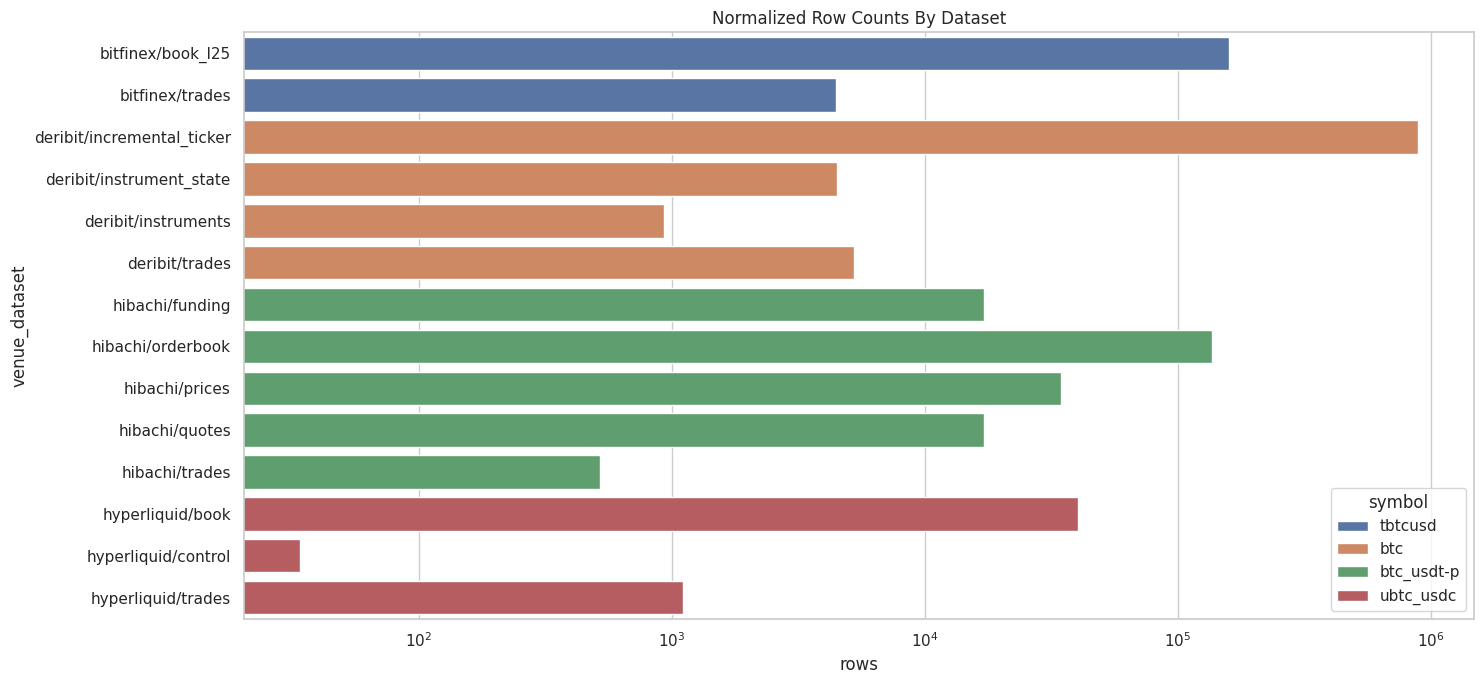

In [7]:
plot_df = coverage.copy()
plot_df["venue_dataset"] = plot_df["exchange"] + "/" + plot_df["dataset"]
plt.figure(figsize=(15, 7))
sns.barplot(data=plot_df, x="rows", y="venue_dataset", hue="symbol", dodge=False)
plt.xscale("log")
plt.title("Normalized Row Counts By Dataset")
plt.tight_layout()

## Time Coverage Plot

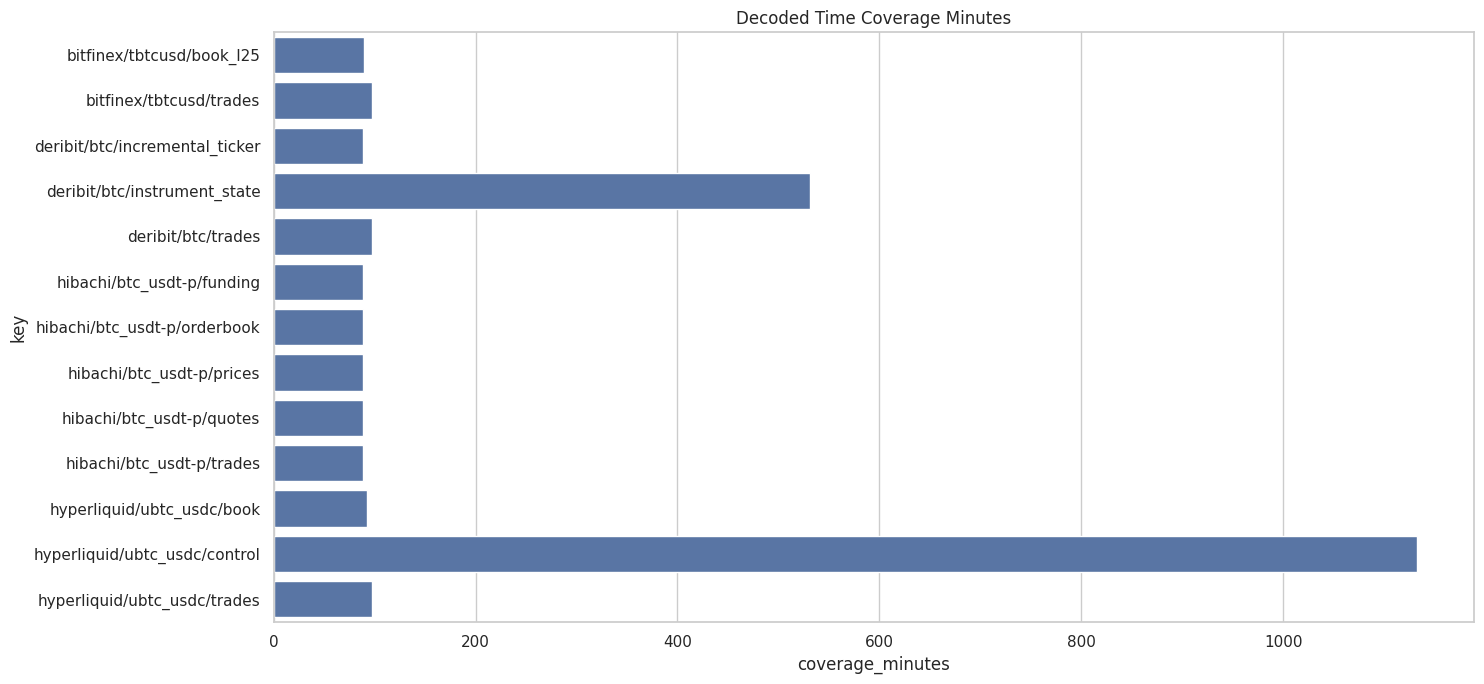

In [8]:
time_df = coverage.dropna(subset=["coverage_minutes"]).copy()
plt.figure(figsize=(15, 7))
sns.barplot(data=time_df, x="coverage_minutes", y="key")
plt.title("Decoded Time Coverage Minutes")
plt.tight_layout()